# 3W Dataset: Domain Distance vs Transfer Penalty

In this notebook, we present two complementary views of the same domain-shift question:

- **Section A** (qualitative): the three domain pairs of the original analysis 
  - Different Sources (Simulated -> Real)
  - Different Wells (1+2 -> 5+10)
  - Different Time Periods (well 2, 2013 -> 2014+2017)
  with a PCA exploration of global vs conditional shift, per-class conditional distances, and the Random Forest transfer penalty per pair.

- **Section B** (quantitative): 20 real-only pairs whose SWD / MMD / FD distances are correlated against the transfer penalty with Spearman / Kendall and block-bootstrap confidence intervals.

Both sections share the same preprocessing, including:
- Raw 56-dim instance features
- A global eval/test split also further used in the `stage3-synthetic_generation/3w_generation.ipynb` notebook on some of these pairs
- An active set of features (21/56) to reduce dimensionality and to avoid well's constant features that would pollute the distance metrics caused by scale floor of the source-fitted scaler on near-constant features (no variance)
- Train-only imputation
- The same distance + transfer penalty computation

## Setup and data loading

In [1]:
import os
import glob
import warnings
import itertools

import numpy as np
import pandas as pd
import scipy.linalg

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wasserstein_distance

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
}

VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
SOURCES = ['real', 'simulated', 'handdrawn']

In [3]:
def detect_source(filename):
    """Determine instance source from filename
    Args:
        filename (str): CSV filename
    Returns:
        str: 'handdrawn', 'simulated', 'real', or 'unknown'
    """
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'):
        return 'handdrawn'
    elif name.startswith('SIMULATED'):
        return 'simulated'
    elif name.startswith('WELL'):
        return 'real'
    return 'unknown'

def load_all_instances(data_dir, class_names):
    """Load all CSV files from the extracted dataset.
    Args:
        data_dir (str): Path to the extracted dataset directory
        class_names (dict): Mapping of class codes to class names
    
    Returns: {class_code: {source: [{id, path, data, n_vars, n_obs}, ...], ...}, ...}
    """
    all_instances = {}
    
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            
            try:
                df = pd.read_csv(fpath)
                if 'timestamp' in df.columns:
                    df['timestamp'] = pd.to_datetime(df['timestamp'])
                
                instance_id = os.path.splitext(fname)[0]
                
                if source not in class_instances:
                    class_instances[source] = []
                class_instances[source].append({
                    'id': instance_id,
                    'path': fpath,
                    'data': df,
                    'n_vars': len([c for c in df.columns if c != 'timestamp' and c != 'class']),
                    'n_obs': df.shape[0],
                })
            except Exception as e:
                print(f'\t[ERROR] {fname}: {e}')
        
        if class_instances:
            all_instances[class_code] = class_instances
    
    return all_instances

data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total = sum(sum(len(lst) for lst in src_dict.values()) for src_dict in data.values())
print(f'Loaded {total} instances across {len(data)} classes.')

Loaded 1984 instances across 9 classes.


## Raw instance features and the eval/reserve split

Each 3W instance is a variable-length event recording, so it is summarized by 7 statistics (`mean`, `std`, `min`, `p25`, `p50`, `p75`, `max`) over its 8 sensors, giving the shared 56-dim feature vector. Per pair, imputation is train-only. The imputation parameters (per-column medians and `inf` clamps) are fit on the source instances and applied to source and target. The target's `NaN`s are therefore never imputed with target information.

## Eval/reserve split

The reserve exists so the synthetic data generation phase can train a CVAE on target-domain data without ever touching the instances used here as transfer test. Every real instance of classes $\{0, 4\}$ is therefore assigned to one of two folds, *eval* or *reserve*, with a fixed 50/50 split stratified by `(well x class)` and a fixed seed. 

Each pair trains on the full source and tests on the **eval** fold of its target, the reserve fold is untouched for the purpose of the synthetic data generation phase. Splitting globally (not per pair) guarantees the same instances are test in every pair that shares a target, and that no reserve instance ever appears in a test set.

In [4]:
stat_names = ['mean', 'std', 'min', 'p25', 'p50', 'p75', 'max']
feature_names = [f'{var}_{stat}' for var in VARIABLE_NAMES for stat in stat_names]
print(f'Feature vector: {len(feature_names)} dimensions')

def get_well_id(inst_id: str):
    """
    Extract well ID from instance ID.
    Args:
        inst_id (str): Instance ID string
    Returns:
        str or None: Well ID if present, otherwise None
    """
    if inst_id.startswith('WELL'):
        return inst_id.split('_')[0]
    return None

def get_year(inst_id: str):
    """
    Return the year from the instance ID if it follows the expected format, otherwise None.
    Args:
        inst_id (str): Instance ID string
    Returns:
        int or None: Year if present, otherwise None
    """
    parts = inst_id.split('_')
    if len(parts) >= 2 and parts[0].startswith('WELL'):
        ts = parts[-1]
        if len(ts) >= 8 and ts[:8].isdigit():
            return int(ts[:4])
    return None

def instance_features(inst: dict) -> np.ndarray:
    """
    56-dim raw feature vector for one instance (NaN/inf kept).
    Args:
        inst (dict): Instance dictionary containing 'data' key with DataFrame
    Returns:
        np.ndarray: 56-dimensional feature vector
    """
    df = inst['data']
    feats = []
    for var in VARIABLE_NAMES:
        if var in df.columns:
            vals = df[var].values
            feats.extend([
                np.nanmean(vals), np.nanstd(vals),
                *np.nanpercentile(vals, [0, 25, 50, 75, 100]),
            ])
        else:
            feats.extend([np.nan] * 7)
    return np.array(feats, dtype=np.float64)

def feature_table(classes, sources, with_meta=False):
    """
    Raw feature table for the given classes/sources (NaN/inf kept).
    Args:
        classes (list): List of class IDs
        sources (list): List of source IDs
        with_meta (bool): Whether to include metadata
    Returns:
        pd.DataFrame: Feature table
    """
    recs = []
    for cls in classes:
        for src in sources:
            for inst in data[cls].get(src, []):
                rec = {'id': inst['id'], 'Class': cls, 'feat': instance_features(inst)}
                if with_meta:
                    rec['well'] = get_well_id(inst['id'])
                    rec['year'] = get_year(inst['id'])
                recs.append(rec)
    df = pd.DataFrame(np.vstack([r['feat'] for r in recs]), columns=feature_names)
    df['id'] = [r['id'] for r in recs]
    df['Class'] = [r['Class'] for r in recs]
    if with_meta:
        df['well'] = [r['well'] for r in recs]
        df['year'] = [r['year'] for r in recs]
    return df

feat_df = feature_table([0, 4], ['real'], with_meta=True)
print(f'Real instances of classes 0 and 4: {len(feat_df)}')

Feature vector: 56 dimensions
Real instances of classes 0 and 4: 941


In [5]:
SPLIT_SEED = 42
RF_SEEDS = [42, 43, 44, 45, 46]

feat_df['fold'] = 'reserve'
for (well, cls), idx in feat_df.groupby(['well', 'Class']).groups.items():
    if len(idx) >= 2:
        ev, _ = train_test_split(list(idx), test_size=0.5, random_state=SPLIT_SEED)
        feat_df.loc[ev, 'fold'] = 'eval'

print('Eval and reserve counts by well x class:')
print(feat_df.groupby(['well', 'Class', 'fold']).size().unstack(fill_value=0))

Eval and reserve counts by well x class:
fold              eval  reserve
well       Class               
WELL-00001 0        47       47
           4        18       18
WELL-00002 0       105      105
           4        56       57
WELL-00003 0        13       13
WELL-00004 0         6        6
           4        21       22
WELL-00005 0        40       41
           4        19       19
WELL-00006 0        57       58
WELL-00007 0         1        1
           4         5        5
WELL-00008 0        28       29
WELL-00010 4        41       42
WELL-00014 4        10       11


In [6]:
W = {'W1': 'WELL-00001', 'W2': 'WELL-00002', 'W4': 'WELL-00004', 'W5': 'WELL-00005'}

def pair(name, axis, src_wells=None, tgt_wells=None, src_years=None, tgt_years=None) -> dict:
    """
    Create a directed source-target pair; family = undirected canonical key.
    Args:
        name (str): Name of the pair
        axis (str): 'year' or 'well'
        src_wells (list): List of source wells
        tgt_wells (list): List of target wells
        src_years (list): List of source years
        tgt_years (list): List of target years
    Returns:
        dict: Dictionary representing the pair with keys 'name', 'axis', 'family', 'src_wells', 'tgt_wells', 'src_years', 'tgt_years'
    """
    if axis == 'year':
        family = frozenset([tuple(src_years), tuple(tgt_years)])
    else:
        family = frozenset([','.join(src_wells), ','.join(tgt_wells)])
    return dict(name=name, axis=axis, family=family,
                src_wells=src_wells, tgt_wells=tgt_wells,
                src_years=src_years, tgt_years=tgt_years)

def domain_rows(wells=None, years=None, fold=None):
    """
    Filter the real {0, 4} feature table.
    Args:
        wells (list): List of well IDs to filter
        years (list): List of years to filter
        fold (str): Fold name to filter ('eval', 'reserve')
    Returns:
        pd.DataFrame: Filtered feature table
    """
    df = feat_df
    if wells is not None:
        df = df[df['well'].isin(wells)]
    if years is not None:
        df = df[df['year'].isin(years)]
    if fold is not None:
        df = df[df['fold'] == fold]
    return df

## Active feature set

A single well can have half of its 56 features (near-)constant: a sensor whose
statistics never move within that well. With the source-fitted scaler, the 1e-3
scale floor then amplifies the target's variation on those features into
meaningless distance contributions (diagnosed on W4: 28/56 constant features
inflate SWD from ~400 to ~1e6). We therefore restrict all distances and the
classifier to the **active feature set**: the features whose per-class standard
deviation is >= 1e-3 in EVERY source subset used by the 20 pairs. The set is
global (the same for all pairs), so the distances stay comparable across pairs,
and the 1e-3 floor never triggers on active features.

In [7]:
MIN_SOURCE_STD = 1e-3

source_subsets = []
for w in W.values():
    for c in [0, 4]:
        source_subsets.append((feat_df['well'] == w, feat_df['Class'] == c))
for y in [2013, 2014]:
    for c in [0, 4]:
        source_subsets.append((feat_df['year'] == y, feat_df['Class'] == c))

active_mask = np.ones(len(feature_names), dtype=bool)
for wm, cm in source_subsets:
    sub = feat_df[wm & cm]
    if len(sub) == 0:
        continue
    std = sub[feature_names].std(axis=0).values
    active_mask &= np.isfinite(std) & (std >= MIN_SOURCE_STD)

ACTIVE_FEATURES = [f for f, a in zip(feature_names, active_mask) if a]
dropped = [f for f, a in zip(feature_names, active_mask) if not a]
print(f'Active features: {len(ACTIVE_FEATURES)}/{len(feature_names)}')
print(f'Dropped ({len(dropped)}): {dropped}')

Active features: 21/56
Dropped (35): ['P-PDG_mean', 'P-PDG_std', 'P-PDG_min', 'P-PDG_p25', 'P-PDG_p50', 'P-PDG_p75', 'P-PDG_max', 'T-JUS-CKP_mean', 'T-JUS-CKP_std', 'T-JUS-CKP_min', 'T-JUS-CKP_p25', 'T-JUS-CKP_p50', 'T-JUS-CKP_p75', 'T-JUS-CKP_max', 'P-JUS-CKGL_mean', 'P-JUS-CKGL_std', 'P-JUS-CKGL_min', 'P-JUS-CKGL_p25', 'P-JUS-CKGL_p50', 'P-JUS-CKGL_p75', 'P-JUS-CKGL_max', 'T-JUS-CKGL_mean', 'T-JUS-CKGL_std', 'T-JUS-CKGL_min', 'T-JUS-CKGL_p25', 'T-JUS-CKGL_p50', 'T-JUS-CKGL_p75', 'T-JUS-CKGL_max', 'QGL_mean', 'QGL_std', 'QGL_min', 'QGL_p25', 'QGL_p50', 'QGL_p75', 'QGL_max']


## Per-pair evaluation: distances and transfer penalty

For each pair we compute, in the active feature space (features that vary in every source subset):

- **Conditional distances** (SWD / MMD / FD): per class {0, 4}

- **Transfer penalty**: for each of the 5 RF seeds, `baseline = CV macro-F1` on the source and `transfer = macro-F1` of a forest trained on the full source and applied to the target-eval, computing the penalty as `baseline - transfer`. We report mean +/- std over the seeds

In [8]:
def fit_imputation(X: np.ndarray) -> dict:
    """
    Fit imputation parameters on the source.
    Args:
        X (np.ndarray): Source feature matrix
    Returns:
        dict: Dictionary containing median, max, and min values for imputation
    """
    med = np.nanmedian(X, axis=0)
    med = np.where(np.isnan(med), 0.0, med)
    c_max = np.full(X.shape[1], 1.0)
    c_min = np.full(X.shape[1], -1.0)
    for j in range(X.shape[1]):
        finite = X[:, j][np.isfinite(X[:, j])]
        if len(finite) > 0:
            c_max[j], c_min[j] = finite.max(), finite.min()
    return {'med': med, 'c_max': c_max, 'c_min': c_min}

def apply_imputation(X: np.ndarray, p: dict) -> np.ndarray:
    """
    Apply fitted imputation to source and target matrices.
    Args:
        X (np.ndarray): Feature matrix to apply imputation
        p (dict): Dictionary containing median, max, and min values for imputation
    Returns:
        np.ndarray: Imputed feature matrix with NaN/inf replaced and values clipped
    """
    X = np.array(X, dtype=np.float64, copy=True)
    X = np.where(np.isnan(X), p['med'], X)        # source median for NaNs
    X = np.where(np.isposinf(X), p['c_max'], X)   # source max for +inf
    X = np.where(np.isneginf(X), p['c_min'], X)   # source min for -inf
    return np.clip(X, -1e15, 1e15)

def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """
    Sliced Wasserstein Distance: mean 1D Wasserstein over random projections.
    Args:
        X (np.ndarray): Source feature matrix
        Y (np.ndarray): Target feature matrix
        n_projections (int): Number of random projections
        random_state (int): Random seed for reproducibility
    Returns:
        float: Mean sliced Wasserstein distance
    """
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    dists = []
    for p in projections:
        dists.append(wasserstein_distance(X @ p, Y @ p))
    return np.mean(dists)

def mmd_rbf(X: np.ndarray, Y: np.ndarray, gamma: float = 0.1) -> float:
    """
    Maximum Mean Discrepancy using an RBF kernel.
    Args:
        X (np.ndarray): Source feature matrix
        Y (np.ndarray): Target feature matrix
        gamma (float): RBF kernel parameter, default 0.1
    Returns:
        float: Maximum Mean Discrepancy value
    """
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """
    Frechet Distance between two multivariate Gaussians fitted to the data.
    Args:
        X (np.ndarray): Source feature matrix
        Y (np.ndarray): Target feature matrix
        eps (float): Small value to add to the diagonal of covariance matrices for numerical stability
    Returns:
        float: Frechet distance value
    """
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    covmean = np.real(covmean)
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

def compute_conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame, class_code: int, min_instances: int = 5, symmetric: bool = True) -> dict | None:
    """
    Conditional distance for a single class in the active feature space.
    Args:
        source_df (pd.DataFrame): Source feature table
        target_df (pd.DataFrame): Target feature table
        class_code (int): Class code to compute distances for
        min_instances (int): Minimum number of instances required in both source and target, otherwise returns None
        symmetric (bool): Whether to fit the scaler on both source and target (True) or only on source (False)
    Returns:
        dict or None: Dictionary with 'SWD', 'MMD', 'FD' distances
    """
    src = source_df[source_df['Class'] == class_code]
    tgt = target_df[target_df['Class'] == class_code]
    if len(src) < min_instances or len(tgt) < min_instances:
        return None

    X = src[ACTIVE_FEATURES].values
    Y = tgt[ACTIVE_FEATURES].values

    scaler = StandardScaler()
    if symmetric:
        scaler.fit(np.vstack([X, Y]))
    else:
        scaler.fit(X)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3) 
    X_scaled = scaler.transform(X)
    Y_scaled = scaler.transform(Y)

    return {
        'SWD': sliced_wasserstein(X_scaled, Y_scaled),
        'MMD': mmd_rbf(X_scaled, Y_scaled),
        'FD': frechet_distance(X_scaled, Y_scaled),
    }

def conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame, classes: list, min_instances: int = 5, symmetric: bool = True) -> dict:
    """
    Helper function to compute conditional distances for each class in the list of classes.
    Args:
        source_df (pd.DataFrame): Source feature table
        target_df (pd.DataFrame): Target feature table
        classes (list): List of class codes to compute distances for
        min_instances (int): Minimum number of instances required in both source and target for each class
        symmetric (bool): Whether to fit the scaler on both source and target (True) or only on source (False)
    Returns:
        dict: Dictionary with averaged 'SWD', 'MMD', 'FD' distances across classes
    """
    dists = [d for cls in classes
             if (d := compute_conditional_distances(source_df, target_df, cls, min_instances, symmetric)) is not None]
    if not dists:
        return {'SWD': np.nan, 'MMD': np.nan, 'FD': np.nan}
    return {m: float(np.mean([d[m] for d in dists])) for m in ['SWD', 'MMD', 'FD']}

def run_transfer_trials_seeded(source_df: pd.DataFrame, target_df: pd.DataFrame, seeds: list, n_trees: int = 100, classes: list = None) -> dict:
    """
    Per-seed transfer penalty computation.
    Args:
        source_df (pd.DataFrame): Source feature table
        target_df (pd.DataFrame): Target feature table
        seeds (list): List of random seeds for reproducibility
        n_trees (int): Number of trees in the Random Forest classifier
        classes (list): List of class codes to compute F1-score for
    Returns:
        dict: Dictionary with mean and std of baseline, transfer, and penalty F1 scores across seeds
    """
    X_src, y_src = source_df[ACTIVE_FEATURES].values, source_df['Class'].values
    X_tgt, y_tgt = target_df[ACTIVE_FEATURES].values, target_df['Class'].values
    labels = sorted(classes) if classes is not None else sorted(np.unique(np.concatenate([y_src, y_tgt])))

    min_class_count = int(np.unique(y_src, return_counts=True)[1].min())
    n_splits = max(2, min(5, min_class_count))
    print(f'Using {n_splits}-fold cross-validation for baseline evaluation (min class count: {min_class_count})')
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    baselines, transfers, penalties = [], [], []
    cls_base, cls_tl, cls_pen = [], [], []
    for seed in seeds:
        rf = RandomForestClassifier(n_estimators=n_trees, random_state=seed, n_jobs=-1)
        y_cv = cross_val_predict(rf, X_src, y_src, cv=skf, n_jobs=-1)
        f1_baseline = f1_score(y_src, y_cv, average='macro')
        rf.fit(X_src, y_src)
        y_pred = rf.predict(X_tgt)
        f1_transfer = f1_score(y_tgt, rf.predict(X_tgt), average='macro')
        baselines.append(f1_baseline)
        transfers.append(f1_transfer)
        penalties.append(f1_baseline - f1_transfer)
        c_base = f1_score(y_src, y_cv, average=None, labels=labels, zero_division=0)
        c_tl = f1_score(y_tgt, y_pred, average=None, labels=labels, zero_division=0)
        cls_base.append(c_base)
        cls_tl.append(c_tl)
        cls_pen.append(c_base - c_tl)

    per_class = pd.DataFrame({
        'class': labels,
        'baseline': np.mean(cls_base, axis=0),
        'transfer': np.mean(cls_tl, axis=0),
        'penalty': np.mean(cls_pen, axis=0),
    })

    return {
        'baseline_mean': np.mean(baselines), 'baseline_std': np.std(baselines),
        'transfer_mean': np.mean(transfers), 'transfer_std': np.std(transfers),
        'penalty_mean': np.mean(penalties), 'penalty_std': np.std(penalties),
        'per_class': per_class
    }

def evaluate_pair(source_df: pd.DataFrame, target_df: pd.DataFrame, classes: list, seeds: list, symmetric_norm: bool = True) -> dict:
    """
    Evaluate the performance of a transfer learning approach on a pair of source and target datasets.
    Args:
        source_df (pd.DataFrame): Source feature table
        target_df (pd.DataFrame): Target feature table
        classes (list): List of class codes on which computing distances
        seeds (list): List of random seeds for reproducibility
        symmetric_norm (bool): Whether to fit the scaler on both source and target (True) or only on source (False)
    Returns:
        dict: Dict with the source-target sizes, computed distances and TL metrics.
    """
    X_src_raw = source_df[ACTIVE_FEATURES].values
    X_tgt_raw = target_df[ACTIVE_FEATURES].values
    imp = fit_imputation(X_src_raw)

    src = pd.DataFrame(apply_imputation(X_src_raw, imp), columns=ACTIVE_FEATURES)
    src['Class'] = source_df['Class'].values
    tgt = pd.DataFrame(apply_imputation(X_tgt_raw, imp), columns=ACTIVE_FEATURES)
    tgt['Class'] = target_df['Class'].values

    dist = conditional_distances(src, tgt, classes, symmetric=symmetric_norm)
    tl = run_transfer_trials_seeded(src, tgt, seeds, classes=classes)
    return {'n_src': len(src), 'n_tgt': len(tgt), **dist, **tl}

## Section A: Three domain pairs, the qualitative distance-vs-penalty comparison

The three domain pairs of the original analysis, now on the shared protocol (active feature space, train-only imputation, eval-fold targets for the real pairs, full target for the cross-source pair, single Random Forest seed 42):

*   **Different Sources (Simulated vs Real):** Instances generated by the OLGA multiphase flow simulator (Source) vs. real wells (Target), over the 6 event classes shared by both sources (1, 2, 3, 5, 6, 8). Full target (simulated data has no eval/reserve split).
*   **Different Wells:** Instances from wells 1+2 (Source) vs. wells 5+10 (Target), over classes 0 (Normal) and 4 (Flow Instability). Target = the **eval** fold.
*   **Different Time Periods:** Instances from well 2 recorded in 2013 (Source) vs. 2014+2017 (Target), over classes 0 and 4. Target = the **eval** fold.


In [9]:
def impute_pair(source_df, target_df):
    """Train-only imputation for one pair: parameters fit on the source only."""
    imp = fit_imputation(source_df[ACTIVE_FEATURES].values)
    src = pd.DataFrame(apply_imputation(source_df[ACTIVE_FEATURES].values, imp),
                       columns=ACTIVE_FEATURES)
    src['Class'] = source_df['Class'].values
    tgt = pd.DataFrame(apply_imputation(target_df[ACTIVE_FEATURES].values, imp),
                       columns=ACTIVE_FEATURES)
    tgt['Class'] = target_df['Class'].values
    return src, tgt

# Different sources (Simulated -> Real), classes 1,2,3,5,6,8
SRC_CLASSES = [1, 2, 3, 5, 6, 8]
src_sim, tgt_real = impute_pair(feature_table(SRC_CLASSES, ['simulated']), feature_table(SRC_CLASSES, ['real']))

print('Different Sources (Simulated -> Real): common classes 1,2,3,5,6,8')
print(f'Source (Simulated): {len(src_sim)} instances over {len(np.unique(src_sim["Class"]))} classes')
print(f'Target (Real): {len(tgt_real)} instances over {len(np.unique(tgt_real["Class"]))} classes')

# Different wells (wells 1+2 -> 5+10), classes 0 and 4
wells_src, wells_tgt = impute_pair(domain_rows(wells=['WELL-00001', 'WELL-00002']), domain_rows(wells=['WELL-00005', 'WELL-00010'], fold='eval'))

print('Different Wells (Wells 1+2 -> 5+10): classes 0 and 4')
print(f'Source (Wells 1+2): {len(wells_src)} instances, target eval (Wells 5+10): {len(wells_tgt)} instances')

# Different time periods (well 2, 2013 -> 2014+2017), classes 0 and 4
time_src, time_tgt = impute_pair(domain_rows(wells=['WELL-00002'], years=[2013]), domain_rows(wells=['WELL-00002'], years=[2014, 2017], fold='eval'))

print('Different Time Periods (well 2, 2013 -> 2014+2017): classes 0 and 4')
print(f'Source (2013): {len(time_src)} instances, target eval (2014+17): {len(time_tgt)} instances')

Different Sources (Simulated -> Real): common classes 1,2,3,5,6,8
Source (Simulated): 939 instances over 6 classes
Target (Real): 80 instances over 6 classes
Different Wells (Wells 1+2 -> 5+10): classes 0 and 4
Source (Wells 1+2): 453 instances, target eval (Wells 5+10): 100 instances
Different Time Periods (well 2, 2013 -> 2014+2017): classes 0 and 4
Source (2013): 31 instances, target eval (2014+17): 145 instances


### Distance metrics

We now compute three mathematically diverse distance metrics to quantify the *conditional domain shift* between the event classes of sources and targets. We will use the following metrics:

- **Sliced Wasserstein Distance (SWD)**: Measures the distance between two probability distributions by projecting them onto one-dimensional subspaces.

- **Maximum Mean Discrepancy (MMD)**: Measures the distance between two probability distributions by comparing their means in a reproducing kernel Hilbert space (RBF kernel). It is useful to capture complex, and non-linear spatial shifts between the different class clusters.

- **Fréchet Distance (FD)**: Computes the mathematical distance between two multivariate Gaussians fitted directly to our feature space. It exploits covariance information to capture the shape of the distributions.

In [10]:
def per_class_distances(source_df: pd.DataFrame, target_df: pd.DataFrame, classes: list):
    """
    Per-class conditional distances via active features.
    Args:
        source_df (pd.DataFrame): Source feature table
        target_df (pd.DataFrame): Target feature table
        classes (list): List of class codes to compute distances for
    Returns:
        pd.DataFrame: DataFrame with per-class distances and instance counts
    """
    per_class = {}
    for cls in classes:
        d = compute_conditional_distances(source_df, target_df, cls)
        if d is not None:
            d['n_src'] = len(source_df[source_df['Class'] == cls])
            d['n_tgt'] = len(target_df[target_df['Class'] == cls])
            per_class[cls] = d
    table = pd.DataFrame(per_class).T.rename_axis('Class')
    print('Conditional distances per class:')
    display(table)
    return table

# Per-class conditional distances for all three domain pairs
per_class_distances(src_sim, tgt_real, SRC_CLASSES)
per_class_distances(wells_src, wells_tgt, [0, 4])
per_class_distances(time_src, time_tgt, [0, 4])

Conditional distances per class:


,SWD,MMD,FD,n_src,n_tgt
Class,,,,,
1,2.752763,0.582000,290.538365,114.0,5.0
2,1.118429,0.691304,41.049677,16.0,22.0
3,1.352987,0.932065,55.958192,74.0,32.0
5,3.104120,0.736250,519.046954,439.0,12.0
6,2.626674,0.739016,307.663071,215.0,6.0


Conditional distances per class:


,SWD,MMD,FD,n_src,n_tgt
Class,,,,,
0,2.397402,1.487250,150.378060,304.0,40.0
4,1.345020,1.047806,52.370731,149.0,60.0


Conditional distances per class:


,SWD,MMD,FD,n_src,n_tgt
Class,,,,,
0,2.528730,1.437167,213.479377,8.0,99.0
4,1.261118,0.723568,48.836069,23.0,46.0


,SWD,MMD,FD,n_src,n_tgt
Class,,,,,
0,2.528730,1.437167,213.479377,8.0,99.0
4,1.261118,0.723568,48.836069,23.0,46.0


Conditional domain distance summary table (mean over classes)


,SWD,MMD,FD
Different sources\n(Simulated vs Real),2.190995,0.736127,242.851252
Different wells\n(Wells 1+2 vs Wells 5+10),1.871211,1.267528,101.374395
"Different time periods\n(Well 2, 2013 vs 2014+2017)",1.894924,1.080367,131.157723


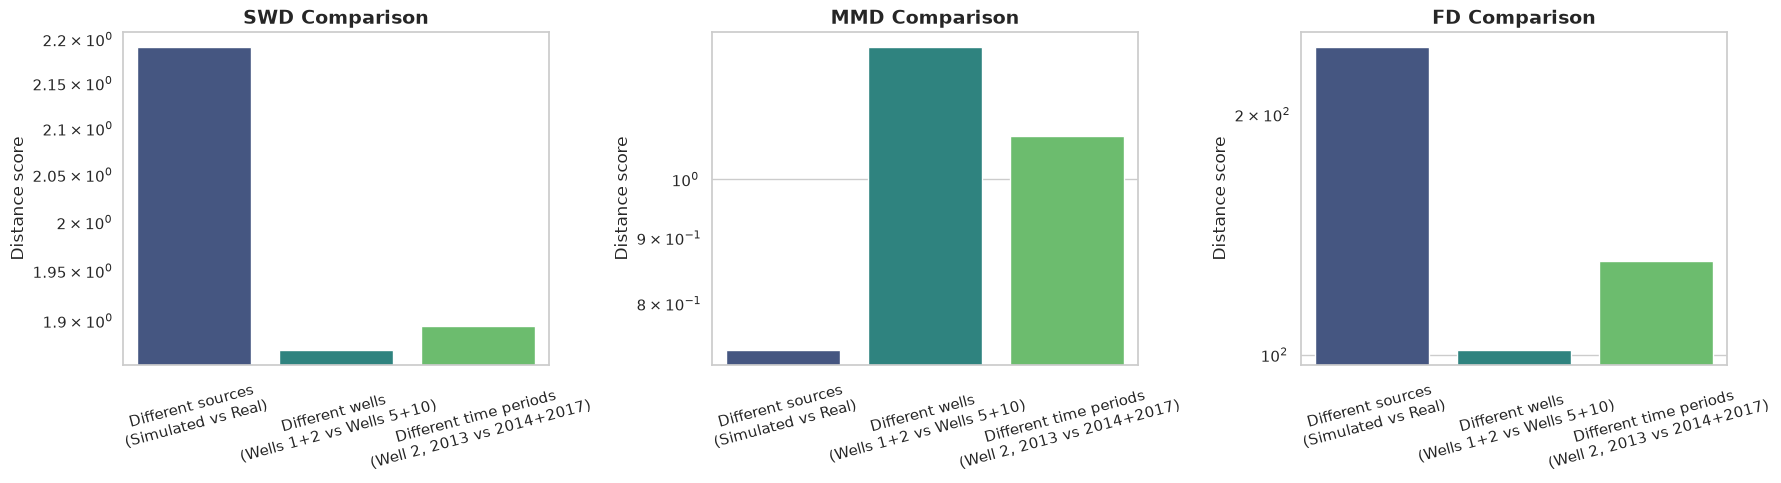

In [11]:
dist = {
    'Different sources\n(Simulated vs Real)':
        conditional_distances(src_sim, tgt_real, SRC_CLASSES, symmetric=True),
    'Different wells\n(Wells 1+2 vs Wells 5+10)':
        conditional_distances(wells_src, wells_tgt, [0, 4], symmetric=True),
    'Different time periods\n(Well 2, 2013 vs 2014+2017)':
        conditional_distances(time_src, time_tgt, [0, 4], symmetric=True),
}
dist_df = pd.DataFrame(dist).T
print("Conditional domain distance summary table (mean over classes)")
display(dist_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['SWD', 'MMD', 'FD']):
    sns.barplot(
        x=dist_df.index,
        y=dist_df[metric],
        ax=axes[i],
        palette='viridis',
        hue=dist_df.index,
        legend=False
    )
    axes[i].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Distance score')
    axes[i].set_xlabel('')
    axes[i].set_yscale('log')
    axes[i].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

### Transfer learning (single RF seed)

To test how domain distance impacts transfer learning performance, we train a Random Forest on the source domains and evaluate it on the target domains.

For each of the three domain gaps, we calculate the drop in the model's F1-score when moved from the `source` to the eval `target` data.

Using 5-fold cross-validation for baseline evaluation (min class count: 16)
Using 5-fold cross-validation for baseline evaluation (min class count: 149)
Using 5-fold cross-validation for baseline evaluation (min class count: 8)


,n_src,n_tgt,SWD,MMD,FD,baseline_mean,transfer_mean,penalty_mean
Different sources\n(Simulated vs Real),939,80,2.190995,0.736127,242.851252,0.986441,0.135863,0.850579
Different wells\n(Wells 1+2 vs Wells 5+10),453,100,1.871211,1.267528,101.374395,0.982528,1.0,-0.017472
"Different time periods\n(Well 2, 2013 vs 2014+2017)",31,145,1.894924,1.080367,131.157723,0.915761,0.240838,0.674923


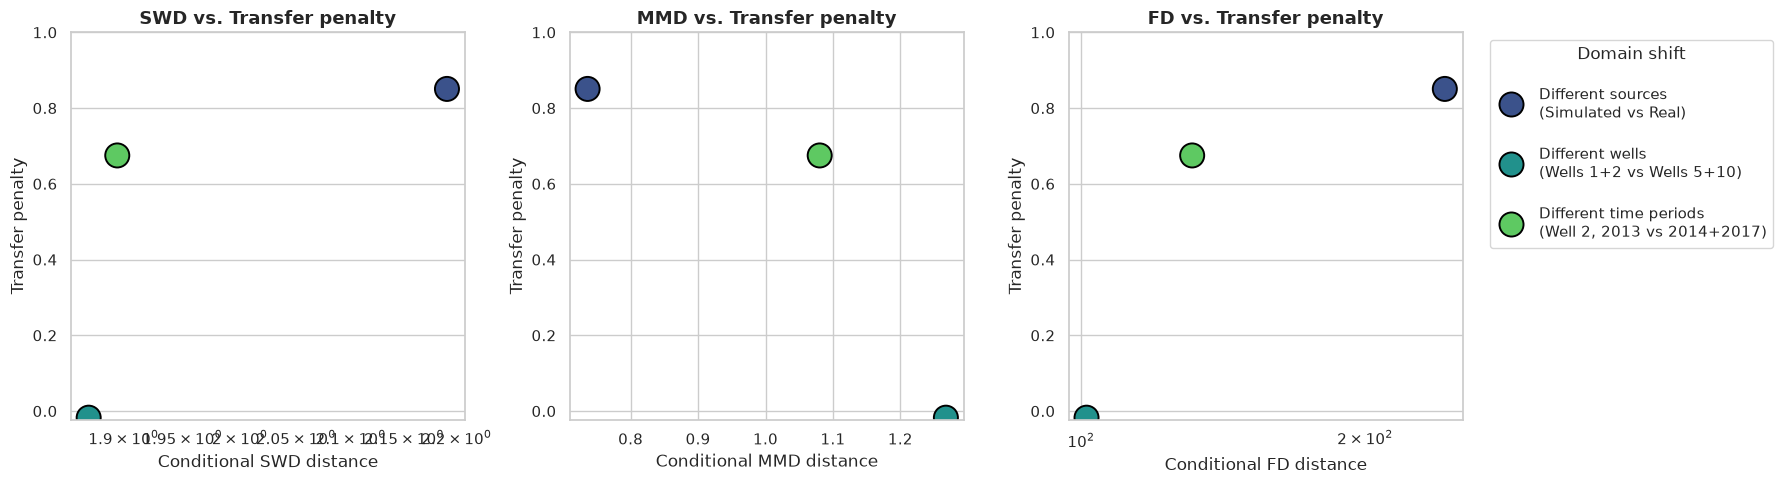

In [12]:
# Transfer penalties for the three domain pairs
eval_results = {
    'Different sources\n(Simulated vs Real)':
        evaluate_pair(src_sim, tgt_real, SRC_CLASSES, seeds=[42]),
    'Different wells\n(Wells 1+2 vs Wells 5+10)':
        evaluate_pair(wells_src, wells_tgt, [0, 4], seeds=[42]),
    'Different time periods\n(Well 2, 2013 vs 2014+2017)':
        evaluate_pair(time_src, time_tgt, [0, 4], seeds=[42]),
}

penalty_df = pd.DataFrame(eval_results).T
display(penalty_df[['n_src', 'n_tgt', 'SWD', 'MMD', 'FD', 'baseline_mean', 'transfer_mean', 'penalty_mean']].round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['SWD', 'MMD', 'FD']):
    sns.scatterplot(
        data=penalty_df,
        x=metric,
        y='penalty_mean',
        hue=penalty_df.index,
        palette='viridis',
        s=300,
        ax=axes[i],
        edgecolor='black'
    )
    # axes[i].set_yscale('symlog', linthresh=0.01)
    axes[i].set_ylim(bottom=penalty_df['penalty_mean'].min() - 0.005, top=1.0)
    axes[i].set_title(f'{metric} vs. Transfer penalty', fontweight='bold', fontsize=13)
    axes[i].set_ylabel('Transfer penalty')
    axes[i].set_xlabel(f'Conditional {metric} distance')

    if metric in ('SWD', 'FD'):
        axes[i].set_xscale('log')
    if i == 2:
        axes[i].legend(title='Domain shift', bbox_to_anchor=(1.05, 1), loc='upper left', labelspacing=1.5)
    else:
        axes[i].get_legend().remove()

plt.tight_layout()

Observing the three domain pairs, we can see that:

1. **Using simulated data as source**: the simulated source transfers poorly to the real target, with the largest penalty of the three pairs and consistently the largest mean-shift distances.

2. **Different wells experiment**: across these different wells the penalty is essentially zero, consistent with the smallest mean-shift distances. MMD is the highest here, showing how the well shift is a covariance-shape change the classifier is able to absorb.

3. **Same well, different time periods**: in this experiment the penalty is much higher than in the wells experiment, and the mean-shift distances are also larger. The time gap transfers worse than the well gap, and the mean-shift metrics rank it accordingly.

Overall, SWD and FD rank the three pairs in the same order as the transfer penalty (Sources > Time > Wells), while MMD doesn't, showing that MMD is not able to accurately capture the transfer ability of the model.

## Section B: Quantitative distance-penalty correlation (20 real-only pairs)

Three source-target pairs (Section A) are enough to show the distance-penalty relationship qualitatively, but too few to speak of a quantitative correlation. We therefore build **20 real-only pairs** over classes 0 (Normal) and 4 (Flow Instability), the only real classes with enough instances across wells, and quantify how well distance metrics predict the transfer penalty with Spearman and Kendall correlations and bootstrap confidence intervals.

## Domain pairs

A domain on 3W could be defined along two axes that are usable with real data only, over the classes 0 and 4:

- **Wells**: 12 single-well pairs among wells 1, 2, 4, 5, selected because the wells with >= 10 instances of both classes.
- **Well groups**: 4 pairs $\{W1,W2\} \longleftrightarrow \{W4,W5\}$ and $\{W1,W5\} \longleftrightarrow \{W2,W4\}$.
- **Time periods**: all real data grouped by year
  - $2013 \to 2014$
  - $2013 \to 2017$
  - $2014 \to 2017$
  - $2013 \to 2014+2017$

In [13]:
pair_specs = []

# 12 single-well pairs
for s, t in itertools.permutations(W.keys(), 2):
    pair_specs.append(pair(f'{s}->{t}', 'well', src_wells=[W[s]], tgt_wells=[W[t]]))

# 4 group pairs of wells
for name, ss, tt in [
    ('{W1,W2}->{W4,W5}', 'W1,W2', 'W4,W5'),
    ('{W4,W5}->{W1,W2}', 'W4,W5', 'W1,W2'),
    ('{W1,W5}->{W2,W4}', 'W1,W5', 'W2,W4'),
    ('{W2,W4}->{W1,W5}', 'W2,W4', 'W1,W5'),
]:
    pair_specs.append(pair(name, 'group', src_wells=[W[x] for x in ss.split(',')], tgt_wells=[W[x] for x in tt.split(',')]))

# 4 year pairs from well 2
for name, sy, ty in [
    ('2013->2014', [2013], [2014]),
    ('2013->2017', [2013], [2017]),
    ('2014->2017', [2014], [2017]),
    ('2013->2014+2017', [2013], [2014, 2017]),
]:
    pair_specs.append(pair(name, 'year', src_years=sy, tgt_years=ty))

rows = []
for spec in pair_specs:
    src = domain_rows(wells=spec['src_wells'], years=spec['src_years'])
    tgt = domain_rows(wells=spec['tgt_wells'], years=spec['tgt_years'], fold='eval')
    rows.append((spec['name'], spec['axis'], len(src), len(tgt), len(tgt[tgt['Class'] == 0]), len(tgt[tgt['Class'] == 4])))

pair_counts = pd.DataFrame(rows, columns=['pair', 'axis', 'n_src', 'n_tgt', 'tgt_c0', 'tgt_c4'])
display(pair_counts)

,pair,axis,n_src,n_tgt,tgt_c0,tgt_c4
0,W1->W2,well,130,161,105,56
1,W1->W4,well,130,27,6,21
2,W1->W5,well,130,59,40,19
3,W2->W1,well,323,65,47,18
4,W2->W4,well,323,27,6,21
5,W2->W5,well,323,59,40,19
6,W4->W1,well,55,65,47,18
7,W4->W2,well,55,161,105,56
8,W4->W5,well,55,59,40,19
9,W5->W1,well,119,65,47,18


In [14]:
rows = []
for spec in pair_specs:
    src = domain_rows(wells=spec['src_wells'], years=spec['src_years'])
    tgt = domain_rows(wells=spec['tgt_wells'], years=spec['tgt_years'], fold='eval')
    r = evaluate_pair(src, tgt, [0, 4], RF_SEEDS)
    r.update(name=spec['name'], axis=spec['axis'], family=spec['family'])
    rows.append(r)

results_df = pd.DataFrame(rows)

cols = ['name', 'axis', 'n_src', 'n_tgt', 'SWD', 'MMD', 'FD', 'baseline_mean', 'transfer_mean', 'penalty_mean', 'penalty_std']
display(results_df[cols].round(4))

# per-class F1 score to check which class (0 or 4) affects the transfer penalty more
per_class_rows = []
for r in rows:
    per_class_rows.append(r['per_class'].assign(name=r['name'], axis=r['axis']))
per_class_df = pd.concat(per_class_rows, ignore_index=True)
print('Per-class transfer learning results (baseline / transfer F1 and penalty, mean over 5 seeds):')
display(per_class_df[['name', 'axis', 'class', 'baseline', 'transfer', 'penalty']].round(3))
results_df = results_df.drop(columns=['per_class'])

Using 5-fold cross-validation for baseline evaluation (min class count: 36)
Using 5-fold cross-validation for baseline evaluation (min class count: 36)
Using 5-fold cross-validation for baseline evaluation (min class count: 36)
Using 5-fold cross-validation for baseline evaluation (min class count: 113)
Using 5-fold cross-validation for baseline evaluation (min class count: 113)
Using 5-fold cross-validation for baseline evaluation (min class count: 113)
Using 5-fold cross-validation for baseline evaluation (min class count: 12)
Using 5-fold cross-validation for baseline evaluation (min class count: 12)
Using 5-fold cross-validation for baseline evaluation (min class count: 12)
Using 5-fold cross-validation for baseline evaluation (min class count: 38)
Using 5-fold cross-validation for baseline evaluation (min class count: 38)
Using 5-fold cross-validation for baseline evaluation (min class count: 38)
Using 5-fold cross-validation for baseline evaluation (min class count: 149)
Using 5-

,name,axis,n_src,n_tgt,SWD,MMD,FD,baseline_mean,transfer_mean,penalty_mean,penalty_std
0,W1->W2,well,130,161,1.3039,0.9847,55.8258,0.9695,0.6345,0.3349,0.2347
1,W1->W4,well,130,27,2.1362,1.4389,125.3590,0.9695,0.4375,0.5320,0.0039
2,W1->W5,well,130,59,1.8675,1.6098,86.1172,0.9695,0.2436,0.7259,0.0039
3,W2->W1,well,323,65,1.6716,0.9049,94.0294,0.9953,0.5842,0.4110,0.0017
4,W2->W4,well,323,27,3.1367,1.3616,292.1196,0.9953,0.4913,0.5039,0.1086
5,W2->W5,well,323,59,2.3822,1.6615,142.5868,0.9953,0.8490,0.1462,0.1284
6,W4->W1,well,55,65,1.8490,1.4178,89.8273,0.9519,0.2169,0.7350,0.0103
7,W4->W2,well,55,161,2.0312,1.3792,119.0455,0.9519,0.2807,0.6712,0.0334
8,W4->W5,well,55,59,1.9391,1.2632,89.9589,0.9519,0.7616,0.1903,0.2984
9,W5->W1,well,119,65,1.8874,1.5801,88.8506,1.0000,0.5038,0.4962,0.1438


Per-class transfer learning results (baseline / transfer F1 and penalty, mean over 5 seeds):


,name,axis,class,baseline,transfer,penalty
0,W1->W2,well,0,0.983,0.801,0.182
1,W1->W2,well,4,0.956,0.468,0.488
2,W1->W4,well,0,0.983,0.000,0.983
3,W1->W4,well,4,0.956,0.875,0.081
4,W1->W5,well,0,0.983,0.000,0.983
5,W1->W5,well,4,0.956,0.487,0.469
6,W2->W1,well,0,0.997,0.597,0.400
7,W2->W1,well,4,0.994,0.571,0.422
8,W2->W4,well,0,0.997,0.100,0.897
9,W2->W4,well,4,0.994,0.883,0.111


## Check the correlation between distance metrics and transfer penalties

The 20 points are not statistically independent, with pairs sharing sources (well or year). We therefore report Spearman $\rho$ and Kendall $\tau$ with 95% confidence intervals from a *bootstrap confidence interval* whose resampling unit is the undirected pair family, with the two directions of a well/group pair, or a single year pair resampled together.

In [15]:
def bootstrap_ci(x: np.ndarray, y: np.ndarray, blocks: list, n_boot: int = 2000, seed: int = 42, stat: str = 'spearman') -> tuple[float, float]:
    """
    Bootstrap confidence interval for correlation between x and y, using block resampling.
    Args:
        x (np.ndarray): First variable
        y (np.ndarray): Second variable
        blocks (list): List of arrays, each containing indices of a block (e.g., family)
        n_boot (int): Number of bootstrap samples
        seed (int): Random seed for reproducibility
        stat (str): 'spearman' or 'kendall' for correlation type
    Returns:
        tuple: Lower and upper bounds of the 95% confidence interval
    """
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_boot):
        idx = np.concatenate([blocks[b] for b in rng.integers(0, len(blocks), size=len(blocks))])
        if len(np.unique(idx)) < 3:
            continue
        if stat == 'spearman':
            v = stats.spearmanr(x[idx], y[idx]).statistic
        else:
            v = stats.kendalltau(x[idx], y[idx]).statistic
        if np.isfinite(v):
            vals.append(v)
    if not vals:
        return (np.nan, np.nan)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return (float(lo), float(hi))

blocks = list(results_df.groupby('family').indices.values())
x = results_df['penalty_mean'].values

corr_summary = {}
for metric in ['SWD', 'MMD', 'FD']:
    y = results_df[metric].values
    rho = stats.spearmanr(x, y).statistic
    tau = stats.kendalltau(x, y).statistic
    rho_ci = bootstrap_ci(x, y, blocks, stat='spearman')
    tau_ci = bootstrap_ci(x, y, blocks, stat='kendall')
    corr_summary[metric] = {'rho': rho, 'rho_ci': rho_ci, 'tau': tau, 'tau_ci': tau_ci}
    print(f'{metric}: Spearman = {rho:+.3f} [{rho_ci[0]:+.3f}, {rho_ci[1]:+.3f}] | Kendall = {tau:+.3f} [{tau_ci[0]:+.3f}, {tau_ci[1]:+.3f}]')

SWD: Spearman = -0.033 [-0.539, +0.457] | Kendall = -0.011 [-0.393, +0.337]
MMD: Spearman = +0.365 [-0.083, +0.693] | Kendall = +0.253 [-0.067, +0.517]
FD: Spearman = -0.038 [-0.525, +0.431] | Kendall = -0.021 [-0.381, +0.296]


## Distance vs penalty plot visualization

Each of the panel plots shows the relationship between one of the three distance metrics (SWD, MMD, FD) and the transfer penalty. The plots allow us to visually assess how well each distance metric correlates with the transfer penalty across the 20 real-only pairs.

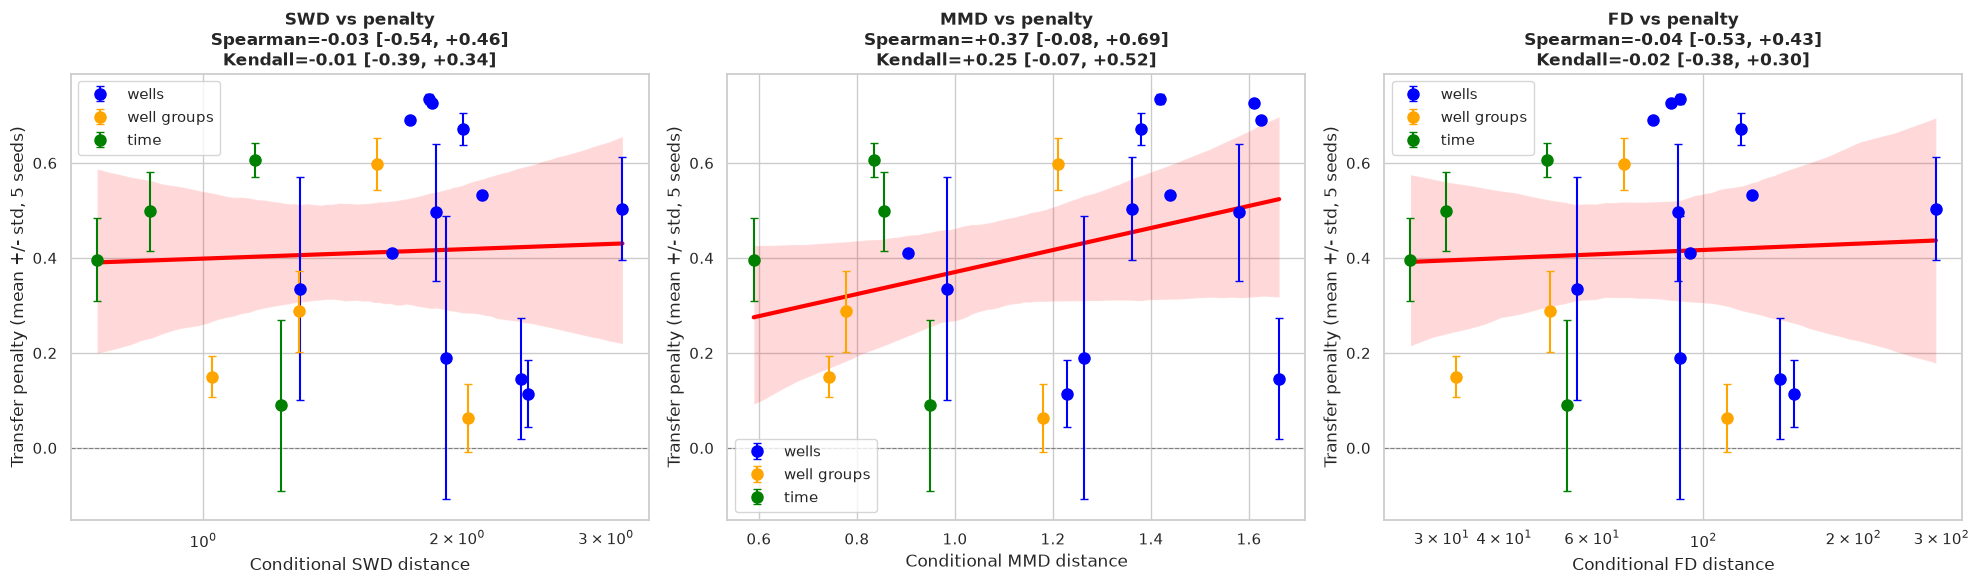

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
palette = {'well': 'blue', 'group': 'orange', 'year': 'green'}
metrics = ['SWD', 'MMD', 'FD']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.regplot(x=metric, y='penalty_mean', data=results_df, ax=ax, scatter=False,
                logx=metric in ('SWD', 'FD'), ci=95,
                line_kws={'color': 'red', 'linewidth': 3})
    for axis in ['well', 'group', 'year']:
        sub = results_df[results_df['axis'] == axis]
        ax.errorbar(sub[metric], sub['penalty_mean'], yerr=sub['penalty_std'],
                    fmt='o', ms=8, capsize=3, color=palette[axis],
                    label={'well': 'wells', 'group': 'well groups', 'year': 'time'}[axis],
                    zorder=3)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    if metric in ('SWD', 'FD'):
        ax.set_xscale('log')
    c = corr_summary[metric]
    ax.set_title(f'{metric} vs penalty\n'
                 f'Spearman={c["rho"]:+.2f} [{c["rho_ci"][0]:+.2f}, {c["rho_ci"][1]:+.2f}]\n'
                 f'Kendall={c["tau"]:+.2f} [{c["tau_ci"][0]:+.2f}, {c["tau_ci"][1]:+.2f}]',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Conditional {metric} distance')
    ax.set_ylabel('Transfer penalty (mean +/- std, 5 seeds)')
    ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## Discussion

Within real 3W data, the mean-shift distances predict the transfer penalty (SWD and FD), while the covariance-shape metric (MMD) does not, this is consistent between the previous qualitative analysis and the quantitative correlation analysis. The main observations are:

1. **Active feature set (21/56)**: only 3 raw features vary across every source subset of the 20 pairs (P-TPT, T-TPT and P-MON-CKP ) the other five variables are
   near-constant in at least one well/class. They are excluded so the distances are comparable across pairs and free from artifacts (very high distances) derived from those constant features.

2. **MMD only captures the domain shift**: observing the correlation between the transfer penalty and the conditional distance, we can see that MMD is the only one that is able to, even if weakly (+0.37 and +0.25) with 0 crossing in the confidence intervals, capture the domain shift, while SWD and FD show no correlation with the transfer penalty. This is inconsistent with the preliminary analysis in Section A, where SWD and FD visually show a better correlation with the transfer penalty.

## Section C: Comparison with source-only (asymmetric) normalization

The Section B distances above were computed under a **symmetric** normalization: the per-class scaler is fit on the union of the source and target instances, so the value does not depend on which side is called `source`. This section repeats the same 20-pair analysis with `symmetric=False`: the per-class scaler is fit on the **source side only**, the directional normalization. Everything else is identical, only the normalization of the distance changes.
This should better capture the unidirectional nature of the transfer penalty, indeed we want to check how well a classifier trained on the source is able to generalize to the target.

In [17]:
rows_src = []
for spec in pair_specs:
    src = domain_rows(wells=spec['src_wells'], years=spec['src_years'])
    tgt = domain_rows(wells=spec['tgt_wells'], years=spec['tgt_years'], fold='eval')
    r = evaluate_pair(src, tgt, [0, 4], RF_SEEDS, symmetric_norm=False)
    r.update(name=spec['name'], axis=spec['axis'], family=spec['family'])
    rows_src.append(r)

results_src_df = pd.DataFrame(rows_src)
cols = ['name', 'axis', 'n_src', 'n_tgt', 'SWD', 'MMD', 'FD', 'baseline_mean',
        'transfer_mean', 'penalty_mean', 'penalty_std']
display(results_src_df[cols].round(4))
results_src_df = results_src_df.drop(columns=['per_class'])

Using 5-fold cross-validation for baseline evaluation (min class count: 36)
Using 5-fold cross-validation for baseline evaluation (min class count: 36)
Using 5-fold cross-validation for baseline evaluation (min class count: 36)
Using 5-fold cross-validation for baseline evaluation (min class count: 113)
Using 5-fold cross-validation for baseline evaluation (min class count: 113)
Using 5-fold cross-validation for baseline evaluation (min class count: 113)
Using 5-fold cross-validation for baseline evaluation (min class count: 12)
Using 5-fold cross-validation for baseline evaluation (min class count: 12)
Using 5-fold cross-validation for baseline evaluation (min class count: 12)
Using 5-fold cross-validation for baseline evaluation (min class count: 38)
Using 5-fold cross-validation for baseline evaluation (min class count: 38)
Using 5-fold cross-validation for baseline evaluation (min class count: 38)
Using 5-fold cross-validation for baseline evaluation (min class count: 149)
Using 5-

,name,axis,n_src,n_tgt,SWD,MMD,FD,baseline_mean,transfer_mean,penalty_mean,penalty_std
0,W1->W2,well,130,161,7.2251,0.4704,2.549573e+03,0.9695,0.6345,0.3349,0.2347
1,W1->W4,well,130,27,19.3357,1.0198,1.482462e+04,0.9695,0.4375,0.5320,0.0039
2,W1->W5,well,130,59,31.5633,1.0240,4.067427e+04,0.9695,0.2436,0.7259,0.0039
3,W2->W1,well,323,65,4.1888,0.5999,7.624650e+02,0.9953,0.5842,0.4110,0.0017
4,W2->W4,well,323,27,16.3854,1.0429,9.636202e+03,0.9953,0.4913,0.5039,0.1086
5,W2->W5,well,323,59,19.6480,1.0827,1.335112e+04,0.9953,0.8490,0.1462,0.1284
6,W4->W1,well,55,65,353.5489,0.2600,5.264650e+06,0.9519,0.2169,0.7350,0.0103
7,W4->W2,well,55,161,498.5990,0.2569,1.104006e+07,0.9519,0.2807,0.6712,0.0334
8,W4->W5,well,55,59,138.2084,0.3222,1.135031e+06,0.9519,0.7616,0.1903,0.2984
9,W5->W1,well,119,65,173.3632,0.2676,1.034923e+06,1.0000,0.5038,0.4962,0.1438


In [18]:
blocks_src = list(results_src_df.groupby('family').indices.values())
x = results_src_df['penalty_mean'].values
corr_summary_src = {}
for metric in ['SWD', 'MMD', 'FD']:
    y = results_src_df[metric].values
    rho = stats.spearmanr(x, y).statistic
    tau = stats.kendalltau(x, y).statistic
    rho_ci = bootstrap_ci(x, y, blocks_src, stat='spearman')
    tau_ci = bootstrap_ci(x, y, blocks_src, stat='kendall')
    corr_summary_src[metric] = {'rho': rho, 'rho_ci': rho_ci, 'tau': tau, 'tau_ci': tau_ci}
    print(f'{metric}: Spearman = {rho:+.3f} [{rho_ci[0]:+.3f}, {rho_ci[1]:+.3f}] | '
          f'Kendall = {tau:+.3f} [{tau_ci[0]:+.3f}, {tau_ci[1]:+.3f}]')

SWD: Spearman = +0.460 [+0.089, +0.760] | Kendall = +0.358 [+0.081, +0.621]
MMD: Spearman = -0.314 [-0.696, +0.112] | Kendall = -0.242 [-0.550, +0.067]
FD: Spearman = +0.423 [+0.007, +0.739] | Kendall = +0.305 [-0.006, +0.580]


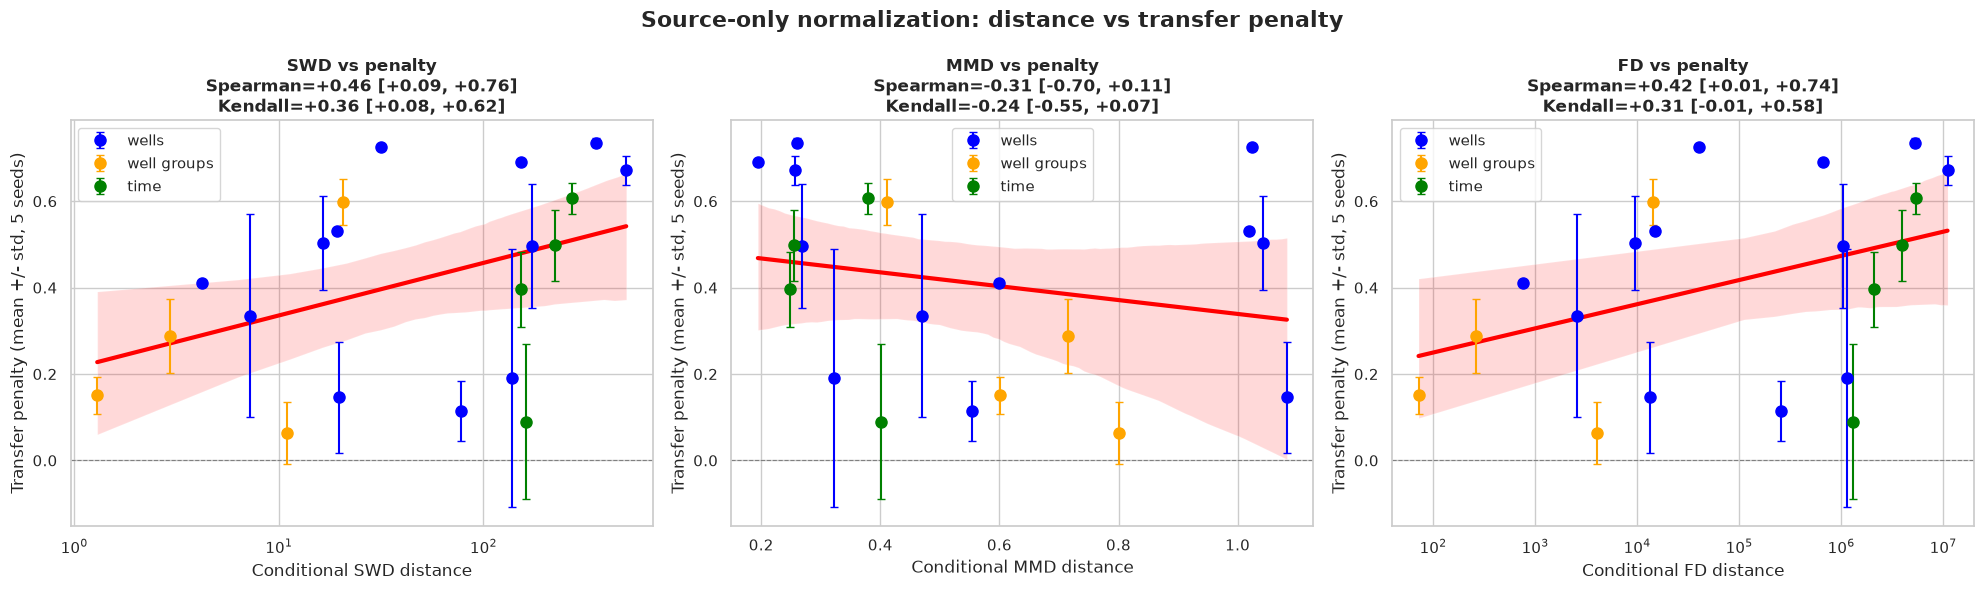

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Source-only normalization: distance vs transfer penalty', fontsize=16, fontweight='bold')
palette = {'well': 'blue', 'group': 'orange', 'year': 'green'}
metrics = ['SWD', 'MMD', 'FD']

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.regplot(x=metric, y='penalty_mean', data=results_src_df, ax=ax, scatter=False,
                logx=metric in ('SWD', 'FD'), ci=95,
                line_kws={'color': 'red', 'linewidth': 3})
    for axis in ['well', 'group', 'year']:
        sub = results_src_df[results_src_df['axis'] == axis]
        ax.errorbar(sub[metric], sub['penalty_mean'], yerr=sub['penalty_std'],
                    fmt='o', ms=8, capsize=3, color=palette[axis],
                    label={'well': 'wells', 'group': 'well groups', 'year': 'time'}[axis],
                    zorder=3)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    if metric in ('SWD', 'FD'):
        ax.set_xscale('log')
    c = corr_summary_src[metric]
    ax.set_title(f'{metric} vs penalty\n'
                 f'Spearman={c["rho"]:+.2f} [{c["rho_ci"][0]:+.2f}, {c["rho_ci"][1]:+.2f}]\n'
                 f'Kendall={c["tau"]:+.2f} [{c["tau_ci"][0]:+.2f}, {c["tau_ci"][1]:+.2f}]',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Conditional {metric} distance')
    ax.set_ylabel('Transfer penalty (mean +/- std, 5 seeds)')
    ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## Conclusion

Across these 3 sections we've explored how different distance metrics combined with different normalization strategies can predict the transfer penalty in the 3W dataset. We identified inconsistencies between some sections, particularly in how the chosen metric distances behave differently under symmetric vs asymmetric normalization. The results suggest that while some metrics may capture certain aspects of domain shift, their predictive power regarding transfer penalty can vary significantly based on the normalization approach used.

Looking at results in Section C, with source-only normalization, we observe that the correlation between distance metrics and transfer penalty is generally stronger compare to symmetric normalization, with SWD and FD showing improved correlation with transfer penalty, while MMD's correlation became weaker. This indicates that the choice of normalization strategy can significantly impact the effectiveness of distance metrics in predicting transfer learning performance, and that source-only normalization may be more appropriate for evaluating transfer learning scenarios where the model is trained on a source domain and applied to a target domain.